#Exercise 1: Decision Tree

Load dataset users.csv
Assign predictors and targets.
Apply encoding using get_dummies().
Split the dataset into train and test data.
Building the model using a decision tree.
Draw decision tree.
Evaluate model performance on train and test sets

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings



In [28]:
user = pd.read_csv("users.csv")

In [29]:
user


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0
...,...,...,...,...,...
94,15786993,Female,45,83000,0
95,15709441,Female,35,44000,0
96,15710257,Female,4,25000,0
97,15582492,Male,5,123000,1


In [30]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          99 non-null     int64 
 1   Gender           99 non-null     object
 2   Age              99 non-null     int64 
 3   EstimatedSalary  99 non-null     int64 
 4   Purchased        99 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [31]:
user.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [32]:
user['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [33]:
user['Purchased'].unique()

array([0, 1])

In [34]:
user['Age'].min()

np.int64(1)

In [35]:
user['Age'].max()

np.int64(64)

In [36]:
user['EstimatedSalary'].mean()


np.float64(57616.16161616162)

In [37]:
user['EstimatedSalary'].max()

np.int64(150000)

In [38]:
X = user.columns.drop('Purchased')
y = user['Purchased']

In [39]:
user_encoded = pd.get_dummies(user[X]).astype(int)

In [40]:
user_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(user_encoded,y, test_size=0.2)

In [42]:
user_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


In [43]:
X_train.shape

(79, 5)

In [44]:
X_test.shape

(20, 5)

In [45]:
y_train.shape

(79,)

In [46]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
train_prediction = model.predict(X_train)
test_prediction = model.predict(X_test)

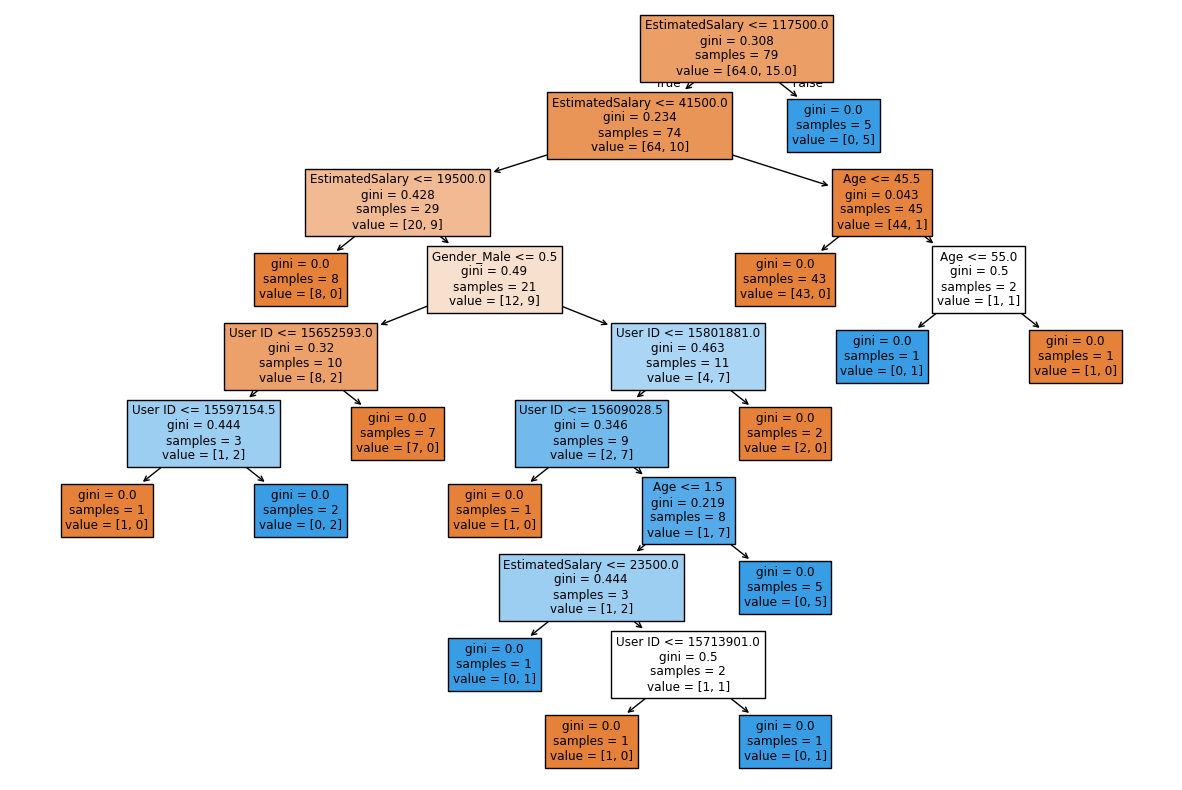

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=user_encoded.columns, filled=True)
plt.show()

In [49]:
# Getting the accuracy on train data
train_accuracy = model.score(X_train,y_train)*100
print("Accuracy of the model on train data = ",train_accuracy)
# Getting the accuracy on test data
test_accuracy = model.score(X_test,y_test)*100
print("Accuracy of the model on test data = ",test_accuracy)

Accuracy of the model on train data =  100.0
Accuracy of the model on test data =  90.0


In [50]:
from sklearn.metrics import classification_report, accuracy_score
warnings.filterwarnings('ignore')

In [53]:
spam_data=pd.read_csv('spambase.csv')


In [54]:
spam_data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [56]:
spam_data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [57]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [58]:
spam_data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [59]:
from sklearn.model_selection import train_test_split
features = spam_data.columns.drop('spam')
target ='spam'
X = spam_data[features]
y = spam_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)


In [60]:
X=spam_data.iloc[:,:-1]               
y=spam_data.iloc[:,-1]                                                                                                                            

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [ ]:
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(n_estimators=10,min_samples_split=20,min_impurity_decrease=0.05)
model.fit(X_train, y_train)
train_accuracy= model.score(X_train, y_train)
test_accuracy= model.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8641304347826086
Testing Accuracy: 0.8816503800217155


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=10)

model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

In [64]:
Y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, Y_pred)
report=classification_report(y_test, Y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(report)

Accuracy: 0.8816503800217155
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       546
           1       0.94      0.75      0.84       375

    accuracy                           0.88       921
   macro avg       0.90      0.86      0.87       921
weighted avg       0.89      0.88      0.88       921

